<!--
Notebook Display Styling

This CSS block standardizes the visual presentation of the notebook when rendered in Jupyter.

Changes applied:

1. Body Text Formatting
   - Sets a consistent font size (15px)
   - Improves readability with increased line spacing (1.6)
   - Ensures uniform text appearance across markdown cells

2. Clear Heading Hierarchy
   - H1 enlarged for main section titles
   - H2 slightly smaller for major subsections
   - H3 for detailed subsections

This improves:
- Visual consistency
- Professional presentation
- Readability in exported HTML reports
-->

<style>
/* Standardize body text formatting */
.jp-RenderedHTMLCommon {
    font-size: 15px;
    line-height: 1.6;
}

/* Improve heading hierarchy clarity */
.jp-RenderedHTMLCommon h1 { font-size: 1.9em; }
.jp-RenderedHTMLCommon h2 { font-size: 1.6em; }
.jp-RenderedHTMLCommon h3 { font-size: 1.3em; }
</style>


# Credit Card Fraud Detection

## 1. 📌 Project Overview
This project explores patterns in credit card transaction data to identify potential indicators of fraudulent behavior. The workflow follows an industry-standard data science pipeline, including data cleaning, feature engineering, exploratory analysis, and predictive modeling.


Special attention is paid to avoiding data leakage and ensuring feature generalizability.

### 📊 Dataset Description:

This is a simulated credit card transaction dataset containing legitimate and fraud transactions from the duration Jan 1st 2019 - Dec 31st 2020. It covers credit cards of 1000 customers doing transactions with a pool and 800 merchants. Each row represents a single credit card transaction enriched with temporal, geographic, and demographic attributes.

The dataset includes:

- Transaction details (transaction amount, transaction category, transaction timestamp)

- Temporal features (hour of transaction, day of week, weekend and nighttime indicators)

- Geographic information (customer location, merchant location, and derived transaction distance)

- Customer demographic attributes (age, gender, occupation, city population, state)

- Behavioral indicators (transaction timing patterns, distance anomalies between customer and merchant)

- Fraud label (binary indicators identifying fraudulent transactions)

The project consists of two separate datasets:

- Training dataset (fraudTrain.csv)

- Testing dataset (fraudTest.csv)

Both datasets share identical schema and variable names, enabling a clean and consistent machine learning pipeline. The testing dataset is reserved for out-of-sample evaluation only and is never used during model training or feature learning.

### 🎯 Objective
The primary objectives of this project are:

- 🧹 Clean and preprocess the transaction dataset, including handling categorical variables, transforming temporal and geographic features, and removing irrelevant or high-risk fields

- 📊 Explore and visualize transaction patterns associated with fraudulent behavior through targeted exploratory data analysis (EDA)

- 🧠 Build and compare classification models for fraud detection (e.g., logistic regression, decision trees, and ensemble methods)

- ⚖️ Address class imbalance inherent in fraud data using techniques such as class weighting or resampling methods

- 📈 Evaluate model performance using appropriate metrics, including precision, recall, F1-score, and confusion matrix, with an emphasis on fraud detection effectiveness

- 🔍 Identify key features and behavioral patterns that contribute to higher fraud risk

- 🔁 Develop a fully reusable preprocessing and modeling pipeline

All feature engineering, transformation, and model training are performed exclusively on the training dataset. The finalized pipeline is then applied unchanged to the testing dataset, ensuring a realistic evaluation setup and eliminating data leakage.

### 📂 Data Source

This dataset was obtained from the [Credit Card Transactions Fraud Detection Dataset](https://www.kaggle.com/datasets/kartik2112/fraud-detection/data).  

#### Load Files

In [49]:
import seaborn as sns
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_recall_curve, RocCurveDisplay, PrecisionRecallDisplay,
    f1_score, recall_score, roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [50]:
fraudTest = pd.read_csv('../../../Data/fraudTest.csv')
fraudTrain = pd.read_csv('../../../Data/fraudTrain.csv')

In [51]:
fraudTrainC = fraudTrain.copy()
fraudTrainC.head(3)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0


#### 📌 Train Dataset Workflow Plan (`fraudTrain.csv`)

This document outlines an **industrial-grade, leakage-safe workflow** for processing and modeling the training dataset (`fraudTrain.csv`).  
All preprocessing rules, feature engineering decisions, and model fitting steps are **learned exclusively from the training data** and later applied unchanged to the test dataset.

---

#### 0. Scope and Objective

- **Objective:**  
  Build a fraud detection model using historical transaction data while avoiding data leakage.
- **Dataset:**  
  `fraudTrain.csv` (transaction-level data)
- **Key Principle:**  
  - No artificial merging of train and test  
  - All `.fit()` operations occur on the training dataset only

---

#### 1. Load Training Data

- Load `fraudTrain.csv` into memory.
- Verify:
  - Number of rows and columns
  - Column names and data types
  - Basic sanity of the dataset

**Deliverables:**
- Dataset shape
- First few rows
- Schema (`info()` output)

---

#### 2. Data Quality and Sanity Checks (Train Only)

- Check missing values by column (percentage).
- Identify duplicate rows if any.
- Inspect basic statistics:
  - Transaction amount (`amt`)
  - Target variable distribution (`is_fraud`)

**Deliverables:**
- Missing value summary
- Fraud rate in training data

---

#### 3. Define Target and Feature Boundary

- Set target variable:
  - `y_train = is_fraud`
- Separate features from the target.
- Identify columns that are:
  - Pure identifiers
  - Personally identifiable information (PII)
  - Candidates for feature engineering
  - Core predictive features

---

#### 4. Column Cleaning Decisions

##### 4.1 Drop Columns Immediately

Remove fields that do not contribute to prediction or may cause leakage:

- `index` (row index)
- `trans_num` (unique transaction identifier)
- `first`, `last` (PII)
- `zip` (high-cardinality noisy location)
- `merchant` (high-cardinality; excluded in baseline model)

---

##### 4.2 Transform Then Drop Raw Fields

- **Transaction timestamp**
  - Source: `trans_date_trans_time`
  - Derived features:
    - `hour`
    - `dayofweek`
    - `month`
    - `is_weekend`
  - Drop raw timestamp after transformation.

- **Date of birth**
  - Source: `dob`
  - Derived feature:
    - `age` at transaction time
  - Drop `dob` after transformation.

---

##### 4.3 Keep for Feature Engineering Only

These fields are **not used directly as model inputs**:

- `cc_num`
  - Used for user-level aggregation and behavior features.
- `unix_time`
  - Used to compute time-gap features between transactions.

---

##### 4.4 Core Features to Retain

- `amt` (and derived `amt_log`)
- `category`
- `city_pop`
- `state` (optional)
- Geographic coordinates (for distance computation):
  - `lat`, `long`
  - `merch_lat`, `merch_long`

---

#### 5. Feature Engineering Plan (Train Only)

##### 5.1 Time-Based Features

Derived from transaction timestamp:

- Hour of day
- Day of week
- Month
- Weekend indicator

---

##### 5.2 Amount-Based Features

- Log transformation:
  - `amt_log = log1p(amt)`
- (Optional) User-relative amount features based on training data only.

---

##### 5.3 Geographic Distance Feature

- Compute distance between:
  - Customer location (`lat`, `long`)
  - Merchant location (`merch_lat`, `merch_long`)
- Resulting feature:
  - `distance_km`
- Drop raw latitude and longitude columns after distance calculation (optional).

---

##### 5.4 Optional User Behavioral Aggregates (Advanced)

Using `cc_num` within training data:

- Transaction count per user
- Average and median transaction amount
- Average transaction distance
- Time gap between consecutive transactions

> All aggregates must be computed **only from training data** and later applied to test data using the same logic.

---

#### 6. Preprocessing Pipeline Definition

- Identify:
  - Numerical feature columns
  - Categorical feature columns
- Preprocessing steps:
  - Numerical:
    - Median imputation
  - Categorical:
    - Most-frequent imputation
    - One-hot encoding (`handle_unknown="ignore"`)
- Use `ColumnTransformer` within an sklearn `Pipeline`.

**Leakage Rule:**  
All preprocessing `.fit()` operations occur on training data only.

---

#### 7. Model Training Strategy

- Baseline model:
  - Logistic Regression with class weighting
- Optional models:
  - Random Forest
  - Gradient Boosting
  - XGBoost (if applicable)

Purpose:
- Establish a strong, interpretable baseline before moving to complex models.

---

#### 8. Validation and Evaluation (Train Phase)

Given severe class imbalance:

- Avoid relying on accuracy alone.
- Primary evaluation metrics:
  - Precision
  - Recall
  - F1-score
  - PR-AUC (Average Precision)

Validation approaches:
- Stratified K-Fold cross-validation (train only)
- Optional time-based split within training data

---

#### 9. Threshold Selection (Business-Oriented)

- Evaluate multiple decision thresholds.
- Select threshold based on:
  - Recall requirements
  - Precision constraints
- Document trade-offs clearly.

---

#### 10. Model Interpretability

- Identify top fraud risk drivers:
  - Coefficients (linear models)
  - Feature importance (tree models)
- Optional:
  - SHAP analysis for model explanations

**Deliverable:**
- Ranked list of transaction-level risk factors.

---

#### 11. Save Artifacts for Reuse

Persist the following for later application to test data:

- Trained preprocessing + model pipeline
- Selected classification threshold
- Evaluation metrics
- Key plots (PR curve, confusion matrix)

Suggested directories:
- `models/`
- `outputs/figures/`
- `outputs/metrics/`

---

#### 12. Application to Test Dataset (Next Phase)

- Load `fraudTest.csv` separately.
- Apply **the same feature engineering and preprocessing pipeline**.
- Use `.transform()` and `.predict()` only.
- Evaluate final model performance on test data.

> This guarantees a leakage-free, forward-looking evaluation consistent with real-world fraud detection systems.


#### 🧪 Schema & Data Quality Checks

In [53]:
fraudTrainC.isna().sum()

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [54]:
fraudTrainC.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


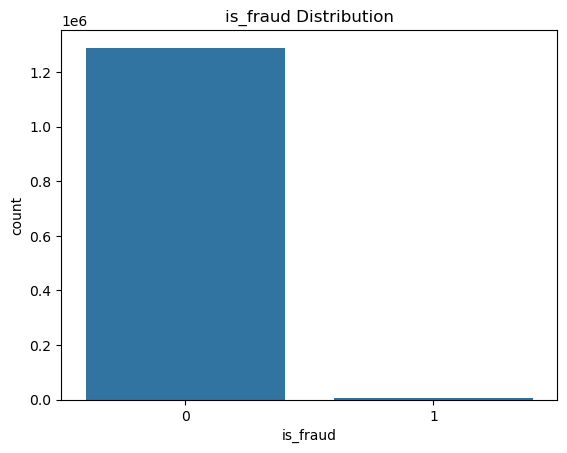

is_fraud
0    99.42%
1     0.58%
Name: proportion, dtype: object

In [55]:
# is_fraud distribution (training set only)
sns.countplot(x='is_fraud', data=fraudTrainC)
plt.title("is_fraud Distribution")
plt.show()

( fraudTrainC['is_fraud'].value_counts(normalize=True) * 100 ).map('{:.2f}%'.format)

#### Dataset Overview

In [56]:
fraudTrain.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [57]:
fraudTest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-nu

## 2. 🧹 Data Processing

### Feature Selection Rationale

Certain raw fields are excluded from modeling due to high cardinality, lack of behavioral meaning, or privacy concerns.

- Identifiers (e.g., transaction ID, index columns) are removed as they do not carry predictive information.
- Raw datetime and location fields are replaced with derived behavioral features.
- Personally identifiable information (PII) is dropped after feature extraction.

These decisions help reduce noise, prevent overfitting, and improve model generalizability.


| Feature Type | Examples | Action |
|-------------|---------|--------|
| Identifiers | trans_num, index | Dropped |
| Time fields | trans_date_trans_time | Transformed |
| Demographics | dob | Derived (age), then dropped |
| Location | lat / long | To be transformed into distance |


I removed obvious identifier and privacy-sensitive fields such as names and street address from the modeling dataset, while retaining operationally useful fields like transaction ID for auditability and ZIP code for potential geographic feature engineering.

In [58]:
# Remove fields that do not contribute to prediction or may cause leakage:
drop_cols = [
    "Unnamed: 0", "first", "last", "street"
]

In [59]:
fraudTrainC = fraudTrainC.drop(columns=drop_cols)
fraudTrainC.head()

,trans_date_trans_time,cc_num,merchant,category,amt,gender,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,M,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [60]:
# Global Average Fraud Rate
print(f"Global Average Fraud Rate: {fraudTrainC['is_fraud'].mean():.4f}\n")

merchant_stats = fraudTrainC.groupby('merchant')['is_fraud'].agg(['count','mean'])

# Top 30 Merchants
print("Top 30 Merchants: \n", merchant_stats.sort_values('mean', ascending=False).head(20))

# Last 30 Merchants
print("\nLast 30 Merchants: \n", merchant_stats.sort_values('mean', ascending=False).tail(20))

Global Average Fraud Rate: 0.0058

Top 30 Merchants: 
                                       count      mean
merchant                                             
fraud_Kozey-Boehm                      1866  0.025723
fraud_Herman, Treutel and Dickens      1300  0.025385
fraud_Kerluke-Abshire                  1838  0.022307
fraud_Brown PLC                        1176  0.022109
fraud_Goyette Inc                      1943  0.021616
fraud_Terry-Huel                       1996  0.021543
fraud_Jast Ltd                         1953  0.021505
fraud_Schmeler, Bashirian and Price    1968  0.020833
fraud_Boyer-Reichert                   1908  0.019916
fraud_Langworth, Boehm and Gulgowski   1969  0.019807
fraud_Moore, Dibbert and Koepp         1266  0.019747
fraud_Baumbach, Feeney and Morar       1929  0.019699
fraud_Rau and Sons                     2490  0.019679
fraud_Gleason-Macejkovic               2033  0.019675
fraud_Kuhic LLC                        1985  0.019647
fraud_Kuhic, Bins and Pfeff

| Merchant | fraud rate |
|------|------------|
| High Risk | 0.02 ~ 0.025（≈ 5x global） |
| Normal | ~0.005 |
| Low Risk | 0 ~ 0.0005 |

In [61]:
category_stats = fraudTrainC.groupby('category')['is_fraud'].agg(['count','mean'])

# Top 30 Merchants
print("Categories: \n", category_stats.sort_values('mean', ascending=False))

# Last 30 Merchants
print("\nLast 30 Categories: \n", category_stats.sort_values('mean', ascending=False))

Categories: 
                  count      mean
category                        
shopping_net     97543  0.017561
misc_net         63287  0.014458
grocery_pos     123638  0.014098
shopping_pos    116672  0.007225
gas_transport   131659  0.004694
misc_pos         79655  0.003139
grocery_net      45452  0.002948
travel           40507  0.002864
entertainment    94014  0.002478
personal_care    90758  0.002424
kids_pets       113035  0.002114
food_dining      91461  0.001651
home            123115  0.001608
health_fitness   85879  0.001549

Last 30 Categories: 
                  count      mean
category                        
shopping_net     97543  0.017561
misc_net         63287  0.014458
grocery_pos     123638  0.014098
shopping_pos    116672  0.007225
gas_transport   131659  0.004694
misc_pos         79655  0.003139
grocery_net      45452  0.002948
travel           40507  0.002864
entertainment    94014  0.002478
personal_care    90758  0.002424
kids_pets       113035  0.002114
food_d

| Category | fraud rate |
|------|------------|
| High Risk | ≈ 3x global |
| Low Risk | ≈ 0.3x global |

In [64]:
import os

data_path = os.path.join("..", "..", "..", "Data", "fraudTrain_cleaned.csv")

fraudTrainC.to_csv(data_path, index=False)

In [65]:
train = pd.read_csv('../../../Data/fraudTrain_cleaned.csv')
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 19 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1296675 non-null  object 
 1   cc_num                 1296675 non-null  int64  
 2   merchant               1296675 non-null  object 
 3   category               1296675 non-null  object 
 4   amt                    1296675 non-null  float64
 5   gender                 1296675 non-null  object 
 6   city                   1296675 non-null  object 
 7   state                  1296675 non-null  object 
 8   zip                    1296675 non-null  int64  
 9   lat                    1296675 non-null  float64
 10  long                   1296675 non-null  float64
 11  city_pop               1296675 non-null  int64  
 12  job                    1296675 non-null  object 
 13  dob                    1296675 non-null  object 
 14  trans_num         